# 03 — Priprema podataka za modelovanje

Ucitavam ocisceni dataset iz notebook 01, radim log-transformaciju, encodujem kategoricke varijable,
delim na train/val/test i skaliram features. Na kraju cuvam sve sto mi treba za trening.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/exoplanet_cleaned.csv")
print(f"Ucitano: {df.shape[0]} redova × {df.shape[1]} kolona")

Ucitano: 2349 redova × 12 kolona


## 1. Log-transformacija

Masa i radijus egzoplaneta pokrivaju vise redova velicine (od sub-Zemljinih do super-Jupiterskih).
Log-transformacija linearizuje mass-radius relaciju i pomaze linearnim modelima. Tree modeli rade i bez nje, ali je korisna za konzistentnu evaluaciju.

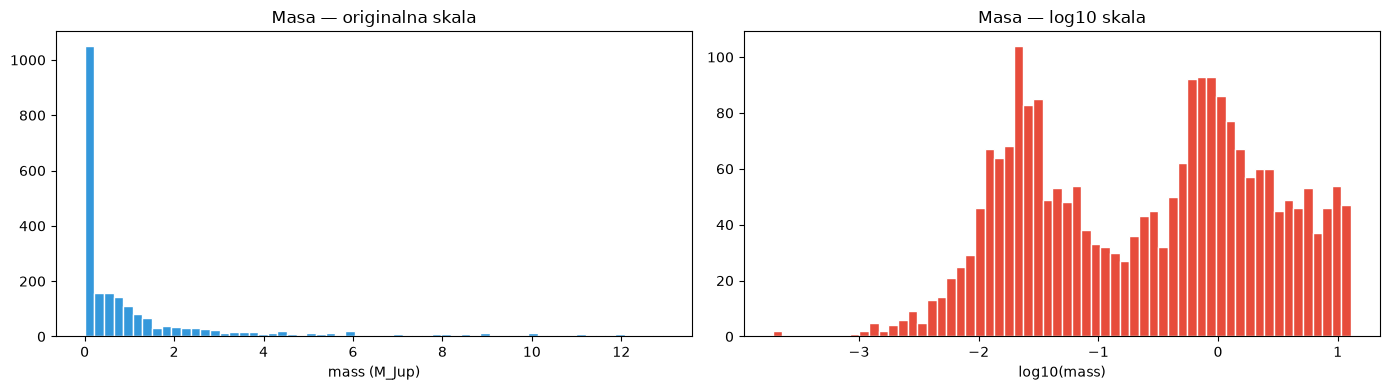

log_mass: count    2349.000
mean       -0.600
std         0.989
min        -3.721
25%        -1.529
50%        -0.419
75%         0.173
max         1.112


In [2]:
df["log_mass"] = np.log10(df["mass"])
df["log_radius"] = np.log10(df["radius"])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["mass"].dropna(), bins=60, color="#3498db", edgecolor="white")
axes[0].set_title("Masa — originalna skala")
axes[0].set_xlabel("mass (M_Jup)")

axes[1].hist(df["log_mass"].dropna(), bins=60, color="#e74c3c", edgecolor="white")
axes[1].set_title("Masa — log10 skala")
axes[1].set_xlabel("log10(mass)")

plt.tight_layout()
plt.show()

print(f"log_mass: {df['log_mass'].describe().round(3).to_string()}")

## 2. Izbor features-a

Na osnovu EDA i korelacione analize, biram finalni set features-a. `name` je samo identifikator, `mass` je target — ne idu u features.
`star_sp_type` ima 250 unikatnih vrednosti i 34% nedostaje — previse kategorija za encoding, izbacujem ga.

In [3]:
numericke_features = [
    "log_radius",
    "orbital_period",
    "semi_major_axis",
    "eccentricity",
    "star_mass",
    "star_radius",
    "star_teff",
    "star_metallicity",
]

kategoricke_features = ["detection_type"]

target = "log_mass"

# Izbacujem redove gde je radius NaN jer je log_radius najbitniji feature
df_model = df.dropna(subset=["log_radius"]).copy()
print(f"Posle izbacivanja redova bez radijusa: {len(df_model)} redova (bilo {len(df)})")

Posle izbacivanja redova bez radijusa: 1754 redova (bilo 2349)


## 3. Encoding kategorickih varijabli

`detection_type` ima 23 kategorije, ali vecina ima manje od 10 planeta. Grupisem retke metode u "Other" pa radim one-hot encoding.

In [4]:
MAIN_METHODS = ["Primary Transit", "Radial Velocity", "Microlensing", "Imaging", "TTV", "Timing", "Astrometry"]

def simplify_detection(method):
    for m in MAIN_METHODS:
        if m in str(method):
            return m
    return "Other"

df_model["detection_simple"] = df_model["detection_type"].apply(simplify_detection)
print("Distribucija posle grupisanja:")
print(df_model["detection_simple"].value_counts())

det_dummies = pd.get_dummies(df_model["detection_simple"], prefix="det", dtype=int)
df_model = pd.concat([df_model, det_dummies], axis=1)

print(f"\nDodato {det_dummies.shape[1]} one-hot kolona: {list(det_dummies.columns)}")

Distribucija posle grupisanja:
detection_simple
Primary Transit    1696
Imaging              25
Radial Velocity      18
TTV                   7
Other                 4
Timing                3
Microlensing          1
Name: count, dtype: int64

Dodato 7 one-hot kolona: ['det_Imaging', 'det_Microlensing', 'det_Other', 'det_Primary Transit', 'det_Radial Velocity', 'det_TTV', 'det_Timing']


## 4. Train / Validation / Test split

Delim podatke na 70% train, 15% validation, 15% test. Bitno je da se split radi **pre skaliranja** da ne bi doslo do data leakage-a.

In [5]:
feature_cols = numericke_features + [c for c in df_model.columns if c.startswith("det_")]

X = df_model[feature_cols]
y = df_model[target]

print(f"X dimenzije: {X.shape}")
print(f"Features: {list(X.columns)}")
print(f"\ny (target = {target}): {y.shape[0]} vrednosti")

X dimenzije: (1754, 15)
Features: ['log_radius', 'orbital_period', 'semi_major_axis', 'eccentricity', 'star_mass', 'star_radius', 'star_teff', 'star_metallicity', 'det_Imaging', 'det_Microlensing', 'det_Other', 'det_Primary Transit', 'det_Radial Velocity', 'det_TTV', 'det_Timing']

y (target = log_mass): 1754 vrednosti


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train: {X_train.shape[0]} redova ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val:   {X_val.shape[0]} redova ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} redova ({X_test.shape[0]/len(X)*100:.0f}%)")

Train: 1227 redova (70%)
Val:   263 redova (15%)
Test:  264 redova (15%)


## 5. Skaliranje numerickih features-a

Koristim StandardScaler — fit-ujem **samo na train setu**, pa transform na val i test. One-hot kolone ne skaliram jer su vec 0/1.

In [7]:
scaler = StandardScaler()

cols_to_scale = numericke_features

X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val_scaled[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Skaliranje zavrseno.")
print(f"\nTrain srednje vrednosti posle skaliranja (trebalo bi ~0):")
print(X_train_scaled[cols_to_scale].mean().round(4).to_string())

Skaliranje zavrseno.

Train srednje vrednosti posle skaliranja (trebalo bi ~0):
log_radius          0.0
orbital_period      0.0
semi_major_axis     0.0
eccentricity        0.0
star_mass           0.0
star_radius         0.0
star_teff           0.0
star_metallicity   -0.0


## 6. Nedostajuce vrednosti — imputacija

Linearni modeli ne mogu da rade sa NaN. Popunjavam medijanom iz train seta (da ne curim informacije iz val/test).

In [8]:
train_medians = X_train_scaled[cols_to_scale].median()

print("Nedostajuce pre imputacije:")
print(f"  Train: {X_train_scaled.isnull().sum().sum()}")
print(f"  Val:   {X_val_scaled.isnull().sum().sum()}")
print(f"  Test:  {X_test_scaled.isnull().sum().sum()}")

X_train_scaled[cols_to_scale] = X_train_scaled[cols_to_scale].fillna(train_medians)
X_val_scaled[cols_to_scale] = X_val_scaled[cols_to_scale].fillna(train_medians)
X_test_scaled[cols_to_scale] = X_test_scaled[cols_to_scale].fillna(train_medians)

print("\nNedostajuce posle imputacije:")
print(f"  Train: {X_train_scaled.isnull().sum().sum()}")
print(f"  Val:   {X_val_scaled.isnull().sum().sum()}")
print(f"  Test:  {X_test_scaled.isnull().sum().sum()}")

Nedostajuce pre imputacije:
  Train: 656
  Val:   163
  Test:  169

Nedostajuce posle imputacije:
  Train: 0
  Val:   0
  Test:  0


## 7. Cuvanje scaler-a i pripremljenih podataka

In [9]:
joblib.dump(scaler, "../models/standard_scaler.pkl")
print("Scaler sacuvan u models/standard_scaler.pkl")

X_train_scaled.to_csv("../data/X_train.csv", index=False)
X_val_scaled.to_csv("../data/X_val.csv", index=False)
X_test_scaled.to_csv("../data/X_test.csv", index=False)
y_train.to_csv("../data/y_train.csv", index=False)
y_val.to_csv("../data/y_val.csv", index=False)
y_test.to_csv("../data/y_test.csv", index=False)

X_train.fillna(train_medians).to_csv("../data/X_train_raw.csv", index=False)
X_val.fillna(train_medians).to_csv("../data/X_val_raw.csv", index=False)
X_test.fillna(train_medians).to_csv("../data/X_test_raw.csv", index=False)

print("Svi setovi sacuvani u data/ folderu")

Scaler sacuvan u models/standard_scaler.pkl
Svi setovi sacuvani u data/ folderu


## 8. Rezime

In [10]:
print("REZIME PRIPREME PODATAKA")
print(f"Target: {target}")
print(f"Broj features-a: {X_train_scaled.shape[1]}")
print(f"  - Numerickih: {len(numericke_features)}")
print(f"  - One-hot (detection): {X_train_scaled.shape[1] - len(numericke_features)}")
print(f"\nDimenzije setova:")
print(f"  Train: {X_train_scaled.shape}")
print(f"  Val:   {X_val_scaled.shape}")
print(f"  Test:  {X_test_scaled.shape}")

REZIME PRIPREME PODATAKA
Target: log_mass
Broj features-a: 15
  - Numerickih: 8
  - One-hot (detection): 7

Dimenzije setova:
  Train: (1227, 15)
  Val:   (263, 15)
  Test:  (264, 15)
